# Dynamic Graph Model Evaluation

Reusable validation diagnostics for one saved dynamic-graph run.

**Only edit `MODEL_DIR`.** Every other experimental choice is written explicitly in the relevant function call so the notebook remains self-documenting.

Graph orientation is always:


$A[\mathrm{target},\mathrm{source}]$


Rows are receiving assets; columns are influencing assets.

The notebook evaluates validation artefacts and post-training counterfactuals. It does not use the held-out proposed-model test split and it does not replace separately trained graph ablations.

In [22]:
# All imports and module setup live in this cell.
# The reload ensures that edits to dynamic_graph_evaluation.py are picked up
# without restarting the notebook kernel.

from pathlib import Path
import importlib
import sys

from IPython.display import display

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import src.evaluation.dynamic_graph_evaluation as dge

dge = importlib.reload(dge)

print("Project root:", project_root)
print("Evaluation module:", dge.__file__)
print("Evaluation module version:", dge.EVALUATION_MODULE_VERSION)

Project root: /Users/vishalruparelia/Desktop/Thesis/dynamic_graphs_thesis
Evaluation module: /Users/vishalruparelia/Desktop/Thesis/dynamic_graphs_thesis/src/evaluation/dynamic_graph_evaluation.py
Evaluation module version: 2026-07-31-v8-error-quantiles


In [50]:
# MODEL_DIR is the only user-configurable global variable.
# Point it at one completed dynamic-graph run directory.
# "free_static_target_entropy_coarse_only_exponential_short_stop"

MODEL_DIR = Path(
    "/Users/vishalruparelia/Library/CloudStorage/"
    "GoogleDrive-vishal@autonomous-fox.ai/"
    "My Drive/dissertation/final_model/initial_test/"
    "free_static_target_entropy_coarse_only_exponential_short_stop"
)

if not MODEL_DIR.is_dir():
    raise FileNotFoundError(
        f"Model directory does not exist: {MODEL_DIR}"
    )

print("Evaluating:", MODEL_DIR)

Evaluating: /Users/vishalruparelia/Library/CloudStorage/GoogleDrive-vishal@autonomous-fox.ai/My Drive/dissertation/final_model/initial_test/free_static_target_entropy_coarse_only_exponential_short_stop


## 1. Model configuration summary

This table reconstructs the saved model and summarises the active architecture:

- **Temporal encoder:** the within-asset causal module used before graph construction.
- **Graph learner:** how the adjacency was supplied or inferred.
- **Spatial module:** how source-node values were aggregated with the graph.
- **Output head:** the parallel or autoregressive future-token predictor.
- **Token target:** whether the model predicted coarse `s1` only or full `s1+s2`.
- **Training loss:** future-position weighting and active graph regularisation.
- **Trainable parameters:** exact trainable parameter count; the frozen Kronos tokenizer/decoder is excluded.

Use `source="best"` for the checkpoint selected by the run's primary validation criterion. Use `"last"` only when deliberately inspecting the final training state.

In [51]:
# source:
#   "best" = primary validation-selected checkpoint.
#   "last" = final completed epoch.
# caption:
#   Optional display title for the table.

display(
    dge.style_model_summary_table(
        MODEL_DIR,
        source="best",
        caption="Validation-selected model configuration",
    )
)

/Users/vishalruparelia/Library/Python/3.12/lib/python/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


,Configuration
Component,
Temporal encoder,"Causal per-node Transformer (1 layer, 4 heads, d_model=64; repeated in 1 ST block)"
Graph learner,BaseDyGraph free-static direct edge logits (2 heads; activation=softmax; self-loops=off)
Spatial module,BaseDyGraph-style graph-weighted value aggregation (2 heads; residual + LayerNorm + FFN; 1 spatial layer per ST block; 1 ST block)
Output head,"Structured-parallel future Transformer (1 layer, 4 heads)"
Token target,Observed context uses s1+s2; predicts coarse s1 only (vocabulary=1024); coarse Kronos decode
Training loss,"s1 cross-entropy; exponential-decay future weights (half-life=5, floor=0.25); target-entropy regularisation (lambda=0.05, H*=2.2)"
Trainable parameters,"412,626 (0.413M; excludes frozen Kronos tokenizer/decoder)"


## 2. Saved validation metrics

This table uses the run's saved decoded validation forecasts.

Generic interpretation:

- **Log MAE:** cumulative-log-change error; lower is better.
- **MASE:** raw error divided by a training-derived one-step scale; lower is better.
- **Relative MAE:** model raw MAE divided by persistence MAE at the same horizon. Values below 1 beat persistence.
- **Win Rate:** fraction of points where the model has lower error than persistence. Values above 0.5 are favourable.
- **Pearson:** pooled correlation of predicted and realised cumulative log changes.
- **IC / Rank IC:** cross-sectional Pearson/Spearman correlation across assets at each origin, then averaged.
- **MMR:** predicted versus realised movement magnitude. Values near 1 are well calibrated; below 1 means under-dispersion.
- **AbsRet Corr:** ability to rank high- versus low-movement periods regardless of sign.

The five horizons must always be read separately even when model selection focuses on 1 and 5 minutes.

In [52]:
# source:
#   "best" = primary validation-selected checkpoint.
#   "last" = final completed epoch.
# channel:
#   Output channel to display; the common benchmark uses "close".
# metrics_to_display:
#   None uses the shared compact table. MASE can be restored later by
#   passing an explicit metric list without changing evaluator code.
# caption:
#   Display title only.

display(
    dge.style_metrics_table(
        MODEL_DIR,
        source="best",
        channel="close",
        metrics_to_display=None,
        caption="Saved validation metrics — primary selected checkpoint",
    )
)

,Log MAE,Log MedAE,Log P95 AE,Rel. MAE,Win Rate,Pearson,IC,Rank IC,MMR,AbsRet Corr
Horizon,,,,,,,,,,
1 min,0.000447108,0.00030899,0.00126696,1.18375,0.404287,-0.00644002,0.0158529,0.0192381,0.543434,0.229284
5 min,0.000924124,0.000666618,0.00260022,1.14685,0.412861,0.0343188,-0.00628382,-0.0101803,0.527873,0.186224
15 min,0.00167836,0.00123978,0.00466206,1.14226,0.406862,0.0190079,-0.00600711,-0.00730692,0.562734,0.146048
30 min,0.00239627,0.00181246,0.00655177,1.18816,0.390379,0.00218921,0.00693346,0.00441618,0.655355,0.109983
60 min,0.00342717,0.0026319,0.00911908,1.20808,0.380277,0.0139519,0.00103245,0.00601433,0.747218,0.0902096


## 3. Graph used for message passing

This heatmap displays the **actual non-negative adjacency** supplied to the spatial layer.

- Rows are target assets.
- Columns are source assets.
- White means zero edge weight.
- Darker red means a larger positive edge weight.
- Clustering changes only the display order; it does not modify or symmetrise the plotted graph.
- `head="mean"` averages graph heads using a predeclared rule rather than selecting the most convenient head.

`source="best_validation"` reads the graph artefact saved during the validation-selected epoch. For a dynamic graph, `window_index=None` displays the mean graph across validation windows; an integer selects one specific saved window.

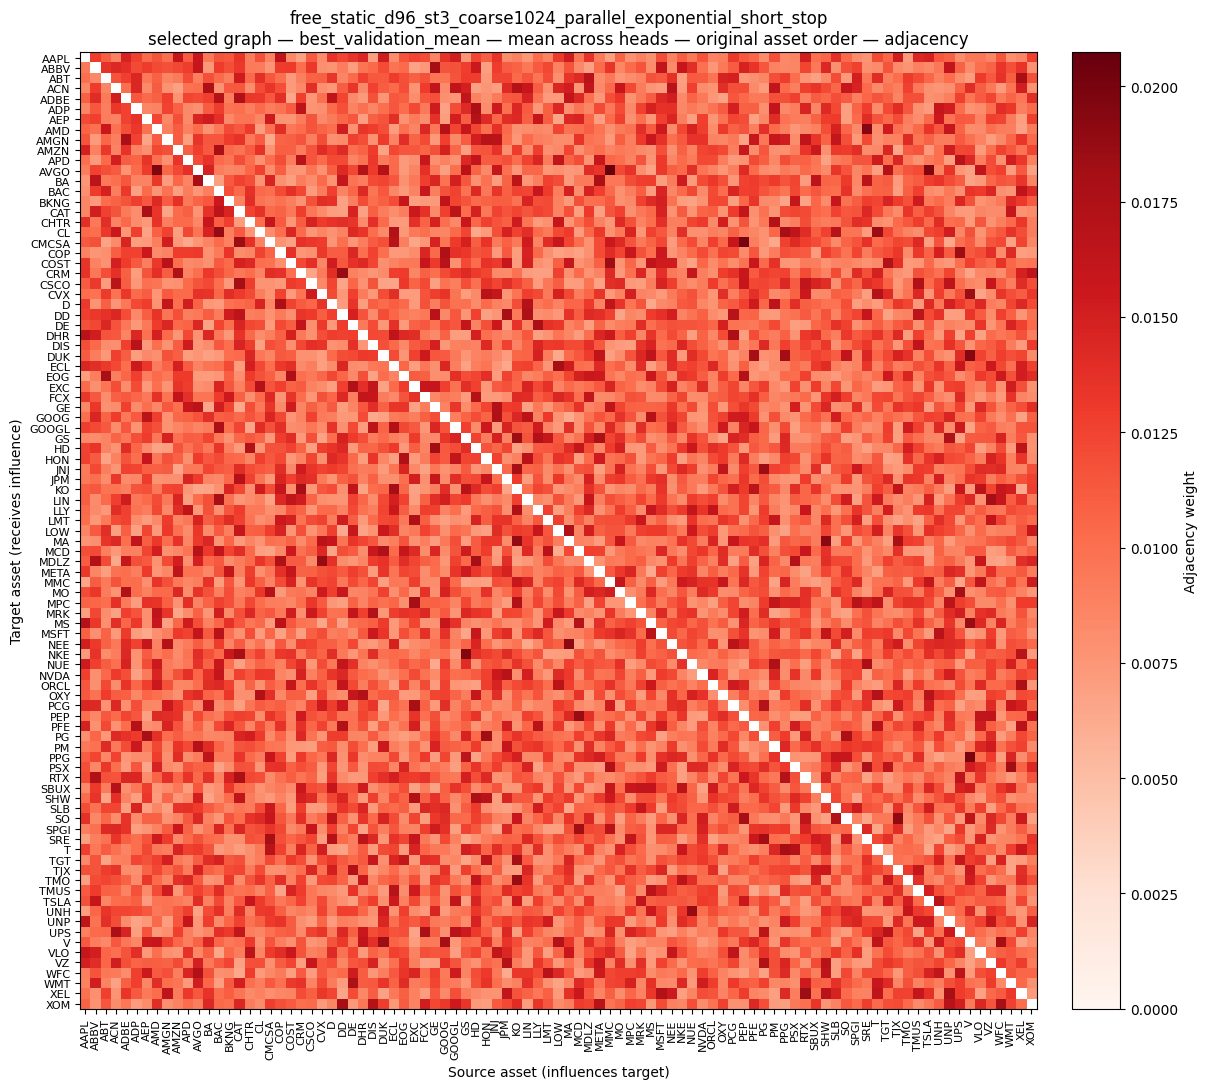

In [42]:
# source:
#   "best_validation" = exact graph artefacts saved at the selected validation epoch.
# component:
#   "selected" = the adjacency actually supplied to spatial message passing.
#   "base" or "dynamic" are available only for compatible dynamic-base runs.
# layer:
#   -1 selects the final graph-bearing ST block.
# head:
#   "mean" averages graph heads; an integer selects one head.
# window_index:
#   None averages saved validation-window graphs; use an integer for one dynamic window.
# cluster / cluster_method:
#   Reorder assets for visual structure only.
# plot_adjacency:
#   True plots the actual adjacency, not deviation from uniform.
# figsize / tick_fontsize / title_fontsize:
#   Control readability while retaining all asset labels.

fig, ax, plotted_graph = dge.plot_learned_graph(
    MODEL_DIR,
    source="best_validation",
    component="selected",
    layer=-1,
    head="mean",
    window_index=None,
    cluster=False,
    cluster_method="average",
    plot_adjacency=True,
    figsize=(13.0, 11.0),
    tick_fontsize=8.0,
    title_fontsize=12.0,
)

## 4. Top graph neighbours

This table converts the adjacency into an asset-level ranking.

With the canonical orientation \(A[\mathrm{target},\mathrm{source}]\):

- `direction="impacted_by"` reads each row and lists the source assets that most influence each target.
- `direction="impacts"` reads each column and lists the target assets most influenced by each source.

The reported weights are graph weights after normalisation. They are routing strength, not signed economic effects. Self-edges are excluded when the run disables self-loops.

In [44]:
# top_n:
#   Number of neighbours to list for every asset.
# direction:
#   "impacted_by" = strongest incoming sources for each target.
#   "impacts" = strongest outgoing targets for each source.
# source / component / layer / head / window_index:
#   Match the graph selection used in the heatmap above.
# caption:
#   Optional display title.

display(
    dge.style_top_neighbours_table(
        MODEL_DIR,
        top_n=5,
        direction="impacts",
        source="best_validation",
        component="selected",
        layer=-1,
        head="mean",
        window_index=None,
        caption="Top incoming graph neighbours",
    )
)

,Neighbour 1,Weight 1,Neighbour 2,Weight 2,Neighbour 3,Weight 3,Neighbour 4,Weight 4,Neighbour 5,Weight 5
Stock,,,,,,,,,,
AAPL,MS,0.017017,DHR,0.016772,UNP,0.016365,VLO,0.015988,NUE,0.015355
ABBV,MDLZ,0.017232,RTX,0.017178,BA,0.016541,TSLA,0.015969,DHR,0.015125
ABT,EOG,0.017742,AMD,0.015607,BAC,0.014857,DE,0.014344,SPGI,0.014181
ACN,UPS,0.017663,SBUX,0.017014,CSCO,0.016649,CL,0.015589,VZ,0.015135
ADBE,AMGN,0.017695,MO,0.017298,MDLZ,0.015983,LIN,0.015157,NUE,0.014713
ADP,PFE,0.016964,DIS,0.016688,MA,0.016121,PM,0.015480,ECL,0.015423
AEP,PG,0.017742,CAT,0.017660,GOOG,0.016633,NEE,0.016013,HON,0.015850
AMD,AVGO,0.019632,MRK,0.016430,V,0.015825,MS,0.015716,ORCL,0.015545
AMGN,NEE,0.017002,COST,0.016687,XEL,0.016434,D,0.016049,PCG,0.015400


## 5. Temporal residual versus graph-message branch

At the selected spatial layer, the model mixes:


$u=\operatorname{LayerNorm}(h+p)$


where $h$ is the temporal representation and $p$ is the graph-routed message.

For the first spatio-temporal block with self-loops disabled, this is the cleanest available comparison between:

- the target asset's own causal history, $h$; and
- cross-asset information routed through the graph, $p$.

The summary reports distributions over validation windows, context minutes and assets:

- **Temporal feature scale:** feature-centred RMS of $h$.
- **Graph branch feature scale:** feature-centred RMS of $p$.
- **Bias-free graph signal scale:** graph signal after removing projection biases.
- **Graph / temporal scale ratio:** relative branch scale. Near zero means a small graph branch; near one means comparable scale.
- **Temporal–graph cosine:** whether the graph reinforces, opposes or adds an approximately orthogonal feature direction.
- **Post-mix LayerNorm graph effect RMS:** change caused by the graph immediately after the first residual and LayerNorm.
- **Full spatial-layer graph effect RMS:** change remaining after the spatial FFN and second residual.

A large graph branch does not prove that the *specific topology* matters; that is tested later with topology counterfactuals.

In [49]:
# source:
#   Checkpoint to reconstruct; "best" is the primary validation-selected model.
# validation_cache_path:
#   None lets the module resolve the validation cache from run metadata/local paths.
# window_indices:
#   None allows the function to select windows according to max_windows.
# max_windows:
#   None uses all validation windows; use 64 for a faster preliminary diagnostic.
# batch_size:
#   Diagnostic inference batch size.
# device:
#   None selects CUDA, then MPS, then CPU.
# use_amp:
#   None follows the saved run's CUDA-AMP setting when CUDA is used.
# block_index / spatial_layer_index:
#   Select the spatial layer to inspect; 0/0 is the first layer.

branch_diagnostics = dge.analyse_spatial_branch_reliance(
    MODEL_DIR,
    source="best",
    validation_cache_path=None,
    window_indices=None,
    max_windows=64,
    batch_size=2,
    device=None,
    use_amp=None,
    block_index=0,
    spatial_layer_index=0,
)

display(
    branch_diagnostics.summary.style
    .format("{:.6f}", na_rep="—")
    .set_caption("Temporal residual versus graph-message branch")
)

/Users/vishalruparelia/Library/Python/3.12/lib/python/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


,Mean,Median,P10,P90
Metric,,,,
Temporal feature scale,1.197889,1.185207,1.094778,1.315998
Graph branch feature scale,0.275788,0.259535,0.211743,0.363502
Bias-free graph signal scale,0.268573,0.253504,0.200871,0.360706
Graph / temporal scale ratio,0.230167,0.220701,0.176749,0.297824
Temporal–graph cosine,0.081038,0.080044,-0.091390,0.255084
Post-mix LayerNorm graph effect RMS,0.217679,0.211980,0.171626,0.272438
Full spatial-layer graph effect RMS,0.202300,0.196019,0.150554,0.264344


### 5.1 Branch influence by asset

This table averages each branch diagnostic over validation windows and context minutes, leaving one row per asset.

Sorting by **Graph / temporal scale ratio** highlights stocks for which the graph branch is large or small relative to their temporal representation. A narrow range suggests a broadly uniform reliance pattern across the universe; a wide range suggests asset-specific use of cross-asset information.

In [29]:
# sort_values:
#   Orders assets from the largest graph-to-temporal scale ratio to the smallest.
# The table contains the same diagnostics as the global summary, averaged by asset.

display(
    branch_diagnostics.per_asset
    .sort_values(
        "Graph / temporal scale ratio",
        ascending=False,
    )
    .style
    .format("{:.6f}", na_rep="—")
    .set_caption("Spatial-branch influence by asset")
)

,Temporal feature scale,Graph branch feature scale,Bias-free graph signal scale,Graph / temporal scale ratio,Temporal–graph cosine,Post-mix LayerNorm graph effect RMS,Full spatial-layer graph effect RMS
Asset,,,,,,,
ADBE,1.270368,0.470714,0.480116,0.366901,0.027109,0.342156,0.346188
PFE,1.271428,0.462502,0.470150,0.361432,0.033695,0.337034,0.335181
BAC,1.290246,0.467821,0.476850,0.359240,0.020324,0.336767,0.341989
SO,1.267840,0.458501,0.465778,0.358747,0.018281,0.336658,0.335055
VZ,1.256937,0.453640,0.461607,0.358193,0.021051,0.336016,0.335716
ABT,1.254000,0.453315,0.460842,0.357820,0.010852,0.335959,0.336314
MPC,1.267838,0.457901,0.464588,0.357660,0.028943,0.334524,0.329744
VLO,1.266978,0.456252,0.464257,0.357411,0.023464,0.334318,0.339468
MS,1.275422,0.459269,0.468876,0.356750,0.009093,0.335811,0.335451


### 5.2 Branch influence over the observed context

This table averages over validation windows and assets, leaving one row for each of the 60 observed context minutes.

It shows whether the graph branch becomes more or less influential toward the forecasting origin. The row labelled minute 60 corresponds to the final observed context position.

In [30]:
# The index is observed-context minute 1...60.
# Each column is averaged over validation windows and assets.

display(
    branch_diagnostics.per_context_position
    .style
    .format("{:.6f}", na_rep="—")
    .set_caption("Spatial-branch influence by observed context minute")
)

,Temporal feature scale,Graph branch feature scale,Bias-free graph signal scale,Graph / temporal scale ratio,Temporal–graph cosine,Post-mix LayerNorm graph effect RMS,Full spatial-layer graph effect RMS
Context minute,,,,,,,
1,1.684046,0.741951,0.757204,0.444618,-0.001163,0.411969,0.455789
2,1.574878,0.618438,0.623639,0.395465,0.073602,0.362898,0.376293
3,1.547034,0.631398,0.642146,0.410872,-0.009762,0.388120,0.410522
4,1.507407,0.741333,0.755510,0.495207,-0.000505,0.454882,0.497230
5,1.471177,0.622501,0.632753,0.425384,-0.002076,0.398184,0.419210
6,1.460029,0.648163,0.658044,0.445660,0.022082,0.410615,0.450496
7,1.431264,0.534056,0.550331,0.375235,0.060352,0.348294,0.366636
8,1.411673,0.576490,0.590658,0.410411,0.013972,0.384305,0.433163
9,1.388871,0.497449,0.507597,0.359591,0.022706,0.340104,0.374457


## 6. Graph-message gate sweep

This post-training intervention scales the trained graph message:

$
u(\gamma)=\operatorname{LayerNorm}(h+\gamma p).
$

- $\gamma=1$ is the exact trained model.
- $\gamma=0$ removes the graph message while preserving the temporal residual.
- Intermediate values test whether reliance changes gradually.

The main columns are:

- **s1 accuracy:** exact coarse-token accuracy under the intervention.
- **s1 argmax change vs actual:** fraction of generated coarse tokens that differ from $\gamma=1$.
- **s1 logit RMS delta vs actual:** magnitude of the change in coarse-token logits.
- **Mean KL(actual || intervention):** distributional change relative to the trained model.
- **h1/h5 CLG-MAE:** decoded short-horizon errors when decoding is enabled.
- **Invalid candle rate:** structural validity of decoded K-lines.

If $\gamma=0$ is nearly identical to $\gamma=1$, the downstream model is largely insensitive to the graph branch. A smooth deterioration as $\gamma$ falls is evidence of reliance.

This is a diagnostic on a trained checkpoint, not a replacement for a separately trained no-graph model.

In [31]:
# gammas:
#   Multipliers applied to the trained graph message; 1.0 must be included.
# max_windows:
#   None uses all validation windows; use 64 for a quicker preliminary pass.
# batch_size:
#   Generation batch size for each intervention.
# device / use_amp:
#   None resolves the available device and follows saved AMP metadata on CUDA.
# block_index / spatial_layer_index:
#   Select the graph-bearing spatial layer.
# decode:
#   True decodes every intervention with the frozen Kronos decoder and computes CLG-MAE.
# decode_series_batch_size:
#   Number of asset-series decoded together.

gate_diagnostics = dge.analyse_graph_gate_sweep(
    MODEL_DIR,
    source="best",
    gammas=(0.0, 0.25, 0.50, 0.75, 1.0),
    validation_cache_path=None,
    forecasting_config_path=None,
    window_indices=None,
    max_windows=64,
    batch_size=1,
    device=None,
    use_amp=None,
    block_index=0,
    spatial_layer_index=0,
    decode=False,
    decode_series_batch_size=64,
)

display(
    gate_diagnostics.summary.style
    .format("{:.6f}", na_rep="—")
    .set_caption("Graph-message gate sweep")
)

/Users/vishalruparelia/Library/Python/3.12/lib/python/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


,Gamma,s1 accuracy,s1 argmax change vs actual,s1 logit RMS delta vs actual,Mean KL(actual || intervention)
Intervention,,,,,
gamma=0,0.000000,0.064085,0.237587,0.702878,0.062896
gamma=0.25,0.250000,0.064973,0.174026,0.488947,0.031860
gamma=0.5,0.500000,0.065919,0.113592,0.308498,0.012707
gamma=0.75,0.750000,0.066700,0.055469,0.147856,0.002845
gamma=1,1.000000,0.066734,0.000000,0.000000,0.000000


### 6.1 Gate sweep by forecast horizon

The horizon table separates the intervention's effects at 1, 5, 15, 30 and 60 minutes.

This is important because a graph may help the short horizons selected during training while having little benefit—or a cost—at later horizons.

In [32]:
# Rows are indexed by graph multiplier and forecast horizon.
# Decoded CLG-MAE is present because decode=True in the previous cell.

display(
    gate_diagnostics.per_horizon.style
    .format("{:.6f}", na_rep="—")
    .set_caption("Graph-message gate sweep by forecast horizon")
)

### 6.2 Gate-sweep visualisation

The plot displays one selected summary metric against the graph-message multiplier.

For decoded short-horizon analysis, lower **Mean h1/h5 CLG-MAE** is better. Other available choices include token argmax-change or KL metrics from the summary table.

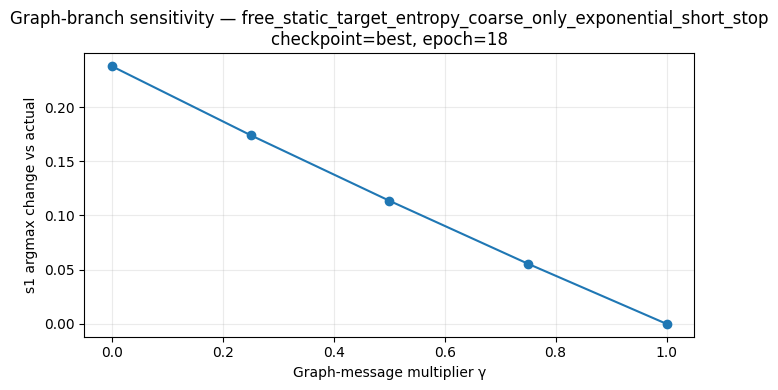

In [33]:
# metric:
#   Column from gate_diagnostics.summary to plot against gamma.
# figsize / marker:
#   Visual formatting only.

fig, ax = dge.plot_graph_gate_sweep(
    gate_diagnostics,
    metric="s1 argmax change vs actual",
    figsize=(7.0, 4.0),
    marker="o",
)

## 7. Graph-topology counterfactuals

This diagnostic separates use of a spatial branch from use of the **specific graph topology**.

The interventions are:

- **actual:** exact adjacency used by the trained model.
- **zero_message:** remove the complete graph message while preserving the temporal residual.
- **uniform:** replace the adjacency with uniform non-self routing.
- **shuffled:** preserve each row's weights, sparsity and entropy, but assign those weights to different source assets.

Generic interpretation:

- `actual ≈ zero_message`: the spatial branch is largely ignored.
- `actual` differs from `zero_message`, but `actual ≈ uniform`: generic cross-asset pooling matters more than topology.
- `actual ≈ shuffled`: weight concentration matters more than source identity.
- `actual` outperforming both `uniform` and `shuffled`: evidence that the particular target–source mapping contributes useful information.

The token/logit columns and decoded metrics have the same definitions as in the gate sweep. These are post-training interventions and must be interpreted alongside separately trained graph ablations.

In [34]:
# interventions:
#   Counterfactual graph/message paths to compare with the exact trained model.
# max_windows:
#   None uses all validation windows; use 64 for a faster preliminary pass.
# batch_size:
#   Generation batch size for each intervention.
# device / use_amp:
#   None resolves the available device and follows saved AMP metadata on CUDA.
# block_index / spatial_layer_index:
#   Select the graph-bearing spatial layer.
# decode:
#   True decodes each counterfactual path and calculates CLG-MAE.
# decode_series_batch_size:
#   Number of asset-series decoded together.
# shuffle_seed:
#   Makes the row-wise source reassignment reproducible.

topology_diagnostics = dge.analyse_graph_topology_counterfactuals(
    MODEL_DIR,
    source="best",
    interventions=(
        "actual",
        "zero_message",
        "uniform",
        "shuffled",
    ),
    validation_cache_path=None,
    forecasting_config_path=None,
    window_indices=None,
    max_windows=None,
    batch_size=2,
    device=None,
    use_amp=None,
    block_index=0,
    spatial_layer_index=0,
    decode=False,
    decode_series_batch_size=64,
    shuffle_seed=42,
)

display(
    topology_diagnostics.summary.style
    .format("{:.6f}", na_rep="—")
    .set_caption("Graph-topology counterfactuals")
)

/Users/vishalruparelia/Library/Python/3.12/lib/python/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


,Gamma,s1 accuracy,s1 argmax change vs actual,s1 logit RMS delta vs actual,Mean KL(actual || intervention)
Intervention,,,,,
actual,—,0.067084,0.000000,0.000000,0.000000
zero_message,—,0.063881,0.241283,0.748881,0.067339
uniform,—,0.067068,0.043169,0.117330,0.001343
shuffled,—,0.066929,0.063054,0.170547,0.002860


### 7.1 Topology counterfactuals by forecast horizon

This table shows whether the actual topology helps consistently or only at particular horizons.

The most important comparison for the current research emphasis is the decoded CLG-MAE at 1 and 5 minutes, while all later horizons remain reported.

In [35]:
# Rows are indexed by intervention and forecast horizon.
# Compare actual with zero_message, uniform and shuffled at each horizon.

display(
    topology_diagnostics.per_horizon.style
    .format("{:.6f}", na_rep="—")
    .set_caption("Graph-topology counterfactuals by forecast horizon")
)

## 8. Reading the diagnostics together

Use the sections jointly:

1. **Branch scale** asks whether the graph message is numerically material before and after spatial normalisation.
2. **Gate sweep** asks whether final token and decoded forecasts depend on the graph-message branch.
3. **Topology counterfactuals** ask whether the exact adjacency matters beyond generic cross-asset pooling.

A large graph/temporal ratio with almost unchanged gate-sweep outputs means downstream layers are insensitive to the spatial change. A material gate effect but no difference between actual, uniform and shuffled graphs means the model uses cross-asset context without relying on the learned/supplied stock-to-stock topology.

Absolute regenerated values can differ slightly from saved CUDA/AMP artefacts when run on another device. Comparisons within one diagnostic call remain controlled because every intervention uses the same checkpoint, windows, device and precision path.

## Coarse-token predictive distribution

This diagnostic runs the selected checkpoint in free-running mode and examines its predicted `s1` distributions. Kronos defines `s1` as the coarse component of its hierarchical financial token, so this analysis concerns the model's 1,024-way coarse-token classifier. 

The diagnostic reports three related but distinct views:

- **Mean per-position entropy and perplexity:** the average uncertainty of one individual token prediction. A perplexity of 100 means that each prediction distributes probability over roughly 100 effective alternatives.
- **Entropy and perplexity of the mean distribution:** how broadly probability mass is spread across token IDs after pooling all selected predictions.
- **Hard-prediction entropy and effective vocabulary:** the diversity of the actual argmax token IDs. This reveals cases where the probability distributions are broad but the same few tokens repeatedly win the argmax.

The plot compares, for the highest-probability tokens:

- mean model probability;
- hard argmax prediction frequency;
- frequency of the same token in the training targets.

The frequency table contains only tokens predicted by hard argmax at least once. Training frequencies are calculated under the same asset and horizon filter as the validation predictions.

When `asset=None`, all assets are pooled. When `horizon=None`, all 60 future positions are pooled. For an autoregressive model, later-horizon distributions are conditional on the model's earlier argmax-generated tokens.

/Users/vishalruparelia/Library/Python/3.12/lib/python/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


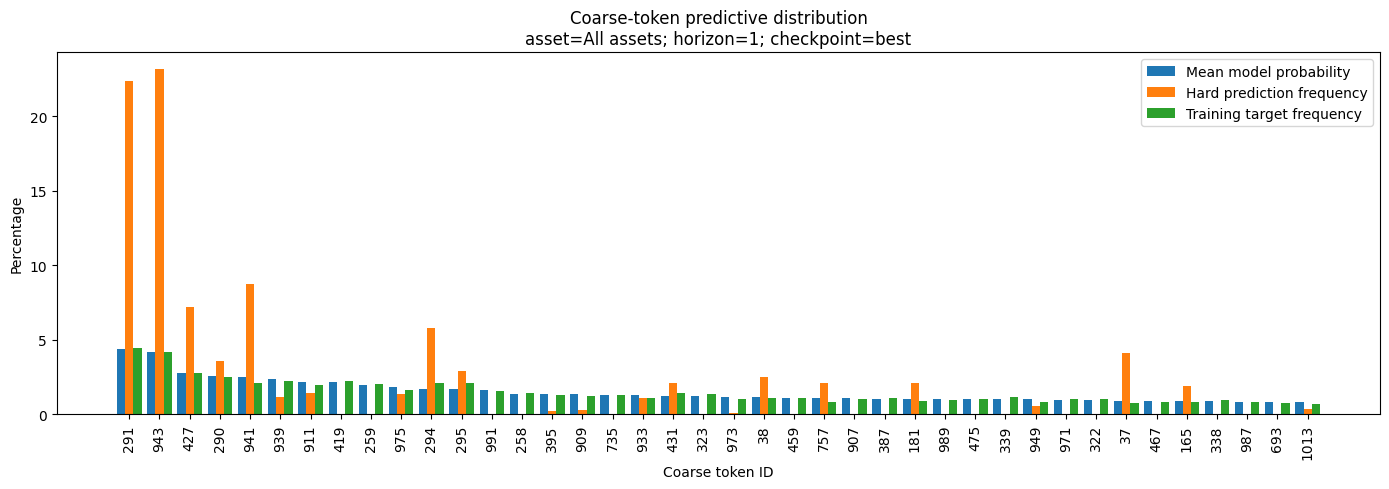

,Checkpoint,Asset,Horizon,Validation windows,Validation predictions,Training targets,Mean per-position entropy (nats),Mean per-position perplexity,Entropy of mean distribution (nats),Perplexity of mean distribution,Hard-prediction entropy (nats),Hard-prediction effective vocabulary,Distinct hard-predicted tokens,Largest hard-prediction share (%),Mean maximum token probability (%)
0,best,All assets,1,380,35340,295089,3.867227,47.810,4.773306,118.310,2.552256,12.836,58,23.144,10.989


,Token ID,Predicted Count,Predicted Frequency (%),Mean Predictive Probability (%),Training Target Count,Training Target Frequency (%)
0,943,8179,23.143746,4.170586,12331,4.178739
1,291,7897,22.345784,4.410003,13196,4.471871
2,941,3083,8.723826,2.519301,6288,2.130883
3,427,2550,7.215620,2.784158,8266,2.801189
4,294,2048,5.795133,1.741820,6302,2.135627
5,37,1467,4.151104,0.911449,2346,0.795014
6,290,1256,3.554046,2.547815,7430,2.517884
7,295,1023,2.894737,1.738941,6256,2.120038
8,38,894,2.529711,1.145576,3331,1.128812
9,46,779,2.204301,0.832332,3008,1.019353


In [36]:
# asset:
#   None pools all assets.
#   A ticker such as "AAPL" restricts the analysis to that asset.
#   A zero-based integer asset index is also accepted.
#
# horizon:
#   None pools all 60 generated future minutes.
#   An integer such as 1, 5, 15, 30 or 60 selects that future minute.
#
# source:
#   "best" uses the primary validation-selected checkpoint.
#   "last" uses the final completed training epoch.
#
# validation_cache_path / training_cache_path:
#   None resolves the cache paths from run metadata and the standard
#   final_model/tokens directory. Pass an explicit path only when needed.
#
# window_indices:
#   None uses the standard window selection controlled by max_windows.
#
# max_windows:
#   None uses every validation window.
#   Use a smaller number such as 64 for a faster preliminary analysis.
#
# batch_size:
#   Validation generation batch size. This analysis does not decode prices.
#
# device:
#   None selects CUDA, then MPS, then CPU.
#
# use_amp:
#   None follows the saved CUDA mixed-precision setting when CUDA is used.
#
# plot_top_n:
#   Number of token IDs displayed in the probability/frequency plot.
#
# figsize:
#   Width and height of the distribution plot.

token_distribution = (
    dge.analyse_token_predictive_distribution(
        MODEL_DIR,
        asset=None,
        horizon=1,
        source="best",
        validation_cache_path=None,
        training_cache_path=None,
        window_indices=None,
        max_windows=None,
        batch_size=2,
        device=None,
        use_amp=None,
        plot_top_n=40,
        figsize=(14.0, 5.0),
    )
)

display(
    token_distribution[
        "figure"
    ]
)

display(
    token_distribution[
        "summary"
    ]
    .style
    .format(
        {
            "Mean per-position entropy (nats)": "{:.6f}",
            "Mean per-position perplexity": "{:.3f}",
            "Entropy of mean distribution (nats)": "{:.6f}",
            "Perplexity of mean distribution": "{:.3f}",
            "Hard-prediction entropy (nats)": "{:.6f}",
            "Hard-prediction effective vocabulary": "{:.3f}",
            "Largest hard-prediction share (%)": "{:.3f}",
            "Mean maximum token probability (%)": "{:.3f}",
        }
    )
    .set_caption(
        "Coarse-token predictive-distribution summary"
    )
)

display(
    token_distribution[
        "token_table"
    ]
    .style
    .format(
        {
            "Predicted Frequency (%)": "{:.6f}",
            "Mean Predictive Probability (%)": "{:.6f}",
            "Training Target Frequency (%)": "{:.6f}",
        }
    )
    .set_caption(
        "Hard-predicted coarse tokens and matched training frequency"
    )
)

## Coarse-token top-k accuracy by future horizon

This diagnostic measures whether the true future `s1` token appears among the model's highest-ranked coarse-token candidates.

For horizon $h$ and rank cutoff $k$:

$$
\operatorname{TopKAcc}_{h,k}
=
\frac{1}{M_h}
\sum_{m=1}^{M_h}
\mathbf 1
\left[
s^{\mathrm{true}}_{m,h}
\in
\operatorname{TopK}
\left(
z_{m,h}
\right)
\right],
$$

where $z_{m,h}$ is the model's 1,024-way `s1` logit vector.

- **Top-1** is exact coarse-token classification accuracy.
- **Top-2 / Top-5 / Top-10** measure whether the correct token is ranked as a plausible alternative even when it does not win the argmax.
- A large gap between Top-1 and Top-10 means the model contains ranking information that hard argmax generation discards.
- Low Top-10 accuracy means the correct token is usually absent even from the model's plausible candidate set.

The model is evaluated in free-running argmax mode. For an autoregressive predictor, later-horizon logits therefore condition on previously generated tokens rather than true future tokens.

Top-k token accuracy does not measure whether an incorrect token is close in BSQ/Hamming space, nor whether it produces a similar decoded candle. Those require separate token-distance and decoded-price diagnostics.

In [37]:
# asset:
#   None pools all 93 assets.
#   A ticker such as "AAPL" evaluates only that asset.
#   A zero-based integer asset index is also accepted.
#
# source:
#   "best" uses the primary validation-selected checkpoint.
#   "last" uses the final completed epoch.
#
# validation_cache_path:
#   None resolves the validation cache from run metadata and the
#   standard final_model/tokens directory.
#
# window_indices:
#   None selects windows according to max_windows.
#
# max_windows:
#   None uses all validation windows.
#   Use a smaller value such as 64 for a faster preliminary check.
#
# batch_size:
#   Number of validation windows generated together.
#
# device:
#   None selects CUDA, then MPS, then CPU.
#
# use_amp:
#   None follows the saved mixed-precision setting when CUDA is used.
#
# top_k_values:
#   Candidate-list sizes tested against the true coarse token.
#
# horizons:
#   None returns all 60 future minutes.
#   Use (1, 5, 15, 30, 60) for only the reported forecast horizons.

s1_topk_accuracy = (
    dge.analyse_s1_topk_accuracy_by_horizon(
        MODEL_DIR,
        asset=None,
        source="best",
        validation_cache_path=None,
        window_indices=None,
        max_windows=None,
        batch_size=2,
        device=None,
        use_amp=None,
        top_k_values=(1,2,5,10,),
        horizons=(1,5,15,30,60),
    )
)

display(
    s1_topk_accuracy.style
    .format(
        "{:.3f}"
    )
    .set_caption(
        "Free-running coarse-token top-k accuracy by future horizon"
    )
)

/Users/vishalruparelia/Library/Python/3.12/lib/python/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
